# ⭐ Actividad 07 — Data Warehouse: Star Schema
---
## Modelo Dimensional — `limon_analytics_db`

```
                   ┌─────────────────────────┐
                   │       dim_tiempo         │
                   │─────────────────────────│
                   │  id_tiempo (PK)          │
                   │  fecha_evento VARCHAR(7) │
                   │  anho       SMALLINT     │
                   │  mes        SMALLINT     │
                   │  trimestre  SMALLINT     │
                   │  month_sin  FLOAT        │
                   │  month_cos  FLOAT        │
                   └─────────┬───────────────┘
                             │ FK
           ┌─────────────────┼─────────────────────┐
           │                 ▼                     │
┌──────────┴──────────┐  ┌──────────────────────────────────────────┐
│   dim_ubicacion     │  │       fact_produccion_limon  ★           │
│─────────────────────│  │──────────────────────────────────────────│
│ id_ubicacion (PK)   │  │ id_hecho         (PK)                   │
│ departamento        ├─►│ id_tiempo        (FK)                   │
│ provincia           │  │ id_ubicacion     (FK)                   │
│ lat  FLOAT          │  │ ── MIDAGRI ──                           │
│ lon  FLOAT          │  │ produccion_t      FLOAT                  │
└─────────────────────┘  │ cosecha_ha        FLOAT                  │
                         │ precio_chacra_kg  FLOAT                  │
                         │ ── INDECI ──                            │
                         │ num_emergencias   INT                    │
                         │ total_afectados   INT                    │
                         │ has_cultivo_perdidas FLOAT               │
                         │ ── AGRARIA.PE ──                        │
                         │ n_noticias        INT                    │
                         │ avg_sentimiento   FLOAT ◄── Fase 2      │
                         │ ── NASA POWER (TODO) ──                 │
                         │ temp_max_c        FLOAT ◄── NASA        │
                         │ precipitacion_mm  FLOAT ◄── NASA        │
                         │ humedad_rel_pct   FLOAT ◄── NASA        │
                         │ velocidad_viento  FLOAT ◄── NASA        │
                         │ radiacion_solar   FLOAT ◄── NASA        │
                         └──────────────────────────────────────────┘
```

| Aspecto | Decisión |
|:--------|:---------|
| **Tipo** | Star Schema (no Snowflake) — JOINs simples para OLAP |
| **Granularidad** | Mensual × Provincia |
| **Llave única** | `(id_tiempo, id_ubicacion)` — UNIQUE |
| **dim_tiempo** | month_sin/cos capturan estacionalidad biológica |
| **NASA** | Columnas reservadas como NULL hasta integración |
| **Sentimiento** | avg_sentimiento llenado en Fase 2 (NLP/BETO) |


In [1]:
%matplotlib inline
import os, sys, json, re, warnings, unicodedata
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
with open('data/02_interim/pipeline_config.json','r',encoding='utf-8') as f:
    CFG = json.load(f)
DIRS=CFG['DIRS']; INTERIM=DIRS['interim']; REPORTS=DIRS['reports']; PROCESSED=DIRS['processed']
print(f"✅ Setup OK | {os.getcwd()}")

✅ Setup OK | C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


## 7.1 Visualización del Diagrama con Matplotlib

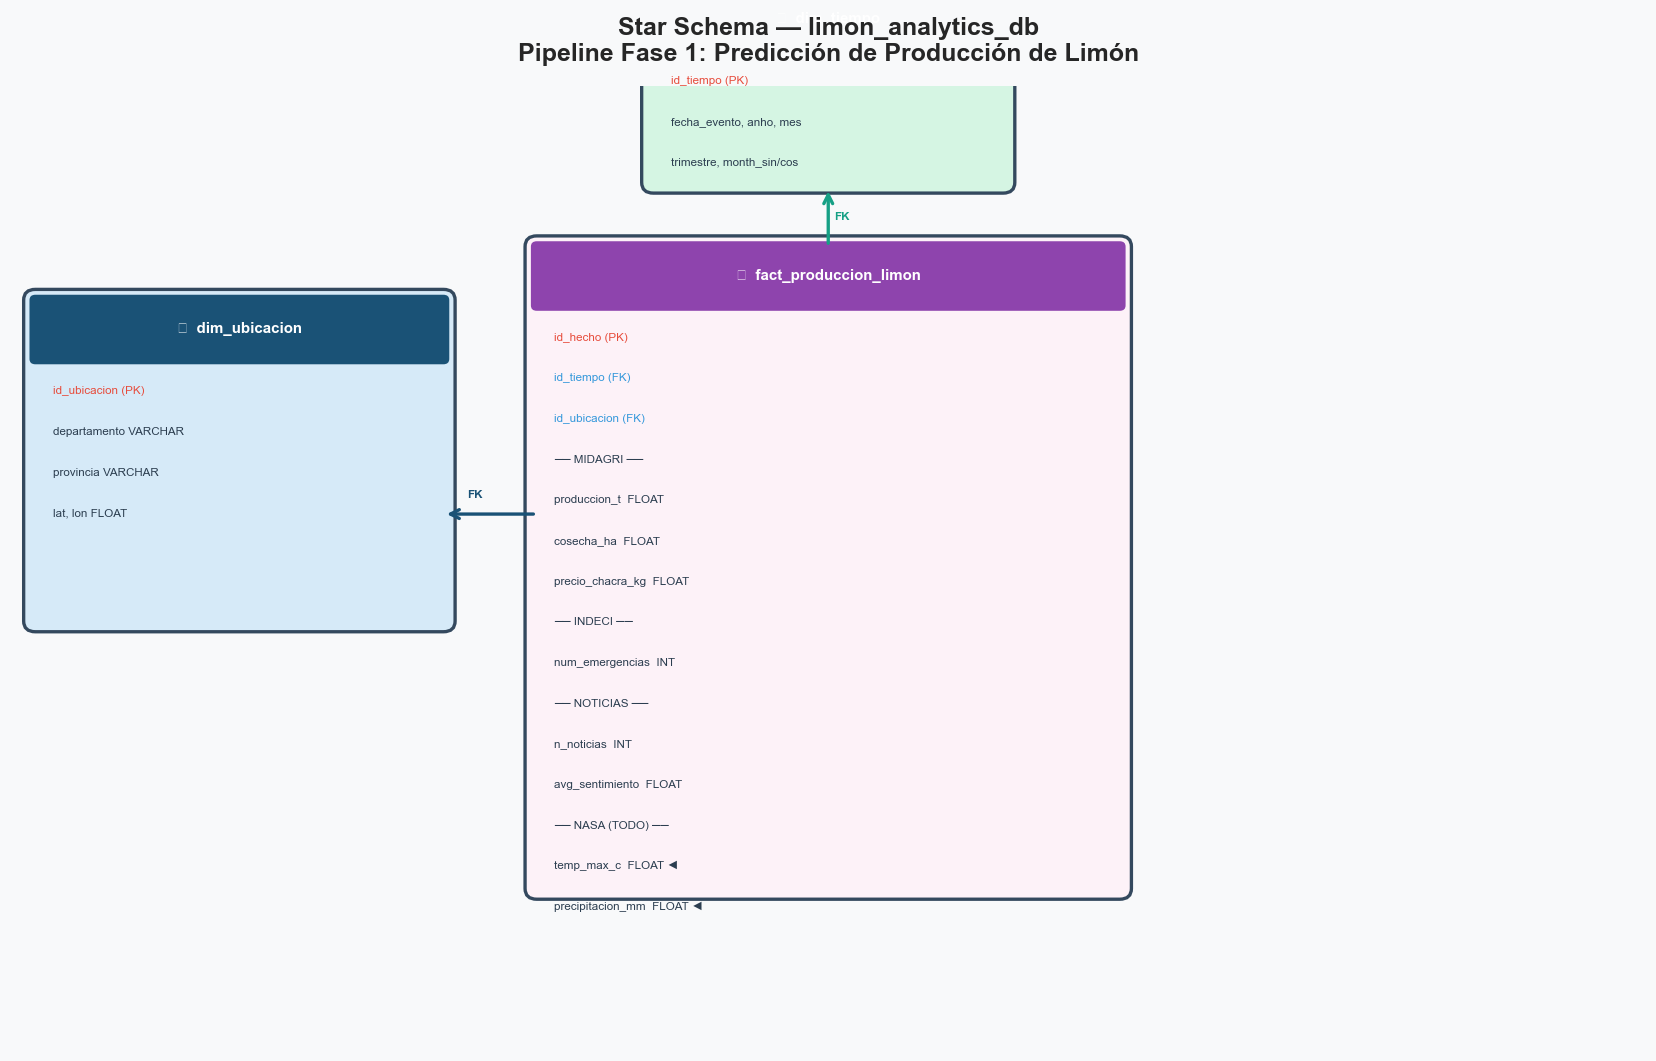

✅ Diagrama Star Schema generado


In [2]:

import matplotlib.patches as mpatches, matplotlib.patheffects as pe

fig,ax=plt.subplots(figsize=(14,9))
ax.set_xlim(0,14); ax.set_ylim(0,9); ax.axis('off')
ax.set_facecolor('#f8f9fa'); fig.patch.set_facecolor('#f8f9fa')
ax.set_title('Star Schema — limon_analytics_db\nPipeline Fase 1: Predicción de Producción de Limón',
             fontsize=15, fontweight='bold', pad=15)

def draw_table(ax, x, y, w, h, title, rows, color_header='#2c3e50', color_bg='#ecf0f1'):
    ax.add_patch(mpatches.FancyBboxPatch((x,y),w,h,boxstyle="round,pad=0.1",
        facecolor=color_bg, edgecolor='#34495e', linewidth=2))
    ax.add_patch(mpatches.FancyBboxPatch((x,y+h-0.55),w,0.55,boxstyle="round,pad=0.05",
        facecolor=color_header, edgecolor='none'))
    ax.text(x+w/2,y+h-0.27,title,ha='center',va='center',fontsize=9,
            fontweight='bold',color='white')
    for i,(row,clr) in enumerate(rows):
        ax.text(x+0.15,y+h-0.85-i*0.38,row,va='center',fontsize=7,
                color='#2c3e50' if clr=='n' else '#e74c3c' if clr=='k' else '#3498db')

# Tabla central — HECHOS
draw_table(ax,4.5,1.5,5,6,'★  fact_produccion_limon',[
    ('id_hecho (PK)','k'),('id_tiempo (FK)','b'),('id_ubicacion (FK)','b'),
    ('── MIDAGRI ──','n'),('produccion_t  FLOAT','n'),('cosecha_ha  FLOAT','n'),
    ('precio_chacra_kg  FLOAT','n'),('── INDECI ──','n'),('num_emergencias  INT','n'),
    ('── NOTICIAS ──','n'),('n_noticias  INT','n'),('avg_sentimiento  FLOAT','n'),
    ('── NASA (TODO) ──','n'),('temp_max_c  FLOAT ◄','n'),('precipitacion_mm  FLOAT ◄','n'),
],'#8e44ad','#fdf2f8')

# dim_tiempo arriba
draw_table(ax,5.5,8.1,3,1.8,'⏰  dim_tiempo',[
    ('id_tiempo (PK)','k'),('fecha_evento, anho, mes','n'),
    ('trimestre, month_sin/cos','n'),
],'#16a085','#d5f5e3')

# dim_ubicacion izquierda
draw_table(ax,0.2,4,3.5,3,'📍  dim_ubicacion',[
    ('id_ubicacion (PK)','k'),('departamento VARCHAR','n'),
    ('provincia VARCHAR','n'),('lat, lon FLOAT','n'),
],'#1a5276','#d6eaf8')

# Flechas
ax.annotate('',xy=(7,7.5),xytext=(7,8.05),arrowprops=dict(arrowstyle='<-',color='#16a085',lw=2))
ax.annotate('',xy=(4.5,5),xytext=(3.7,5),arrowprops=dict(arrowstyle='<-',color='#1a5276',lw=2))
ax.text(3.9,5.15,'FK',fontsize=7,color='#1a5276',fontweight='bold')
ax.text(7.05,7.75,'FK',fontsize=7,color='#16a085',fontweight='bold')

plt.tight_layout()
plt.savefig(f"{REPORTS}/g07_star_schema.png",dpi=150,bbox_inches='tight')
plt.show()
print("✅ Diagrama Star Schema generado")


## 7.2 DDL del Star Schema

In [3]:

DDL='''CREATE TABLE IF NOT EXISTS dim_tiempo (
    id_tiempo SERIAL PRIMARY KEY, fecha_evento VARCHAR(7) NOT NULL UNIQUE,
    anho SMALLINT NOT NULL, mes SMALLINT NOT NULL, trimestre SMALLINT,
    month_sin FLOAT, month_cos FLOAT);

CREATE TABLE IF NOT EXISTS dim_ubicacion (
    id_ubicacion SERIAL PRIMARY KEY, departamento VARCHAR(60) NOT NULL,
    provincia VARCHAR(60) NOT NULL, lat FLOAT, lon FLOAT,
    UNIQUE(departamento,provincia));

CREATE TABLE IF NOT EXISTS fact_produccion_limon (
    id_hecho SERIAL PRIMARY KEY,
    id_tiempo INT NOT NULL REFERENCES dim_tiempo(id_tiempo),
    id_ubicacion INT NOT NULL REFERENCES dim_ubicacion(id_ubicacion),
    produccion_t FLOAT DEFAULT 0, cosecha_ha FLOAT DEFAULT 0, precio_chacra_kg FLOAT,
    num_emergencias INT DEFAULT 0, total_afectados INT DEFAULT 0,
    has_cultivo_perdidas FLOAT DEFAULT 0, n_noticias INT DEFAULT 0,
    avg_sentimiento FLOAT, temp_max_c FLOAT, temp_min_c FLOAT,
    precipitacion_mm FLOAT, humedad_rel_pct FLOAT, velocidad_viento FLOAT,
    radiacion_solar FLOAT, UNIQUE(id_tiempo,id_ubicacion));'''
import os
sql_path=f"{DIRS['database']}/dwh_star_schema.sql"
with open(sql_path,'w',encoding='utf-8') as f: f.write(DDL)
print(DDL); print(f"\n[OK] {sql_path}")
print("✅ [ACTIVIDAD 07] COMPLETADA")


CREATE TABLE IF NOT EXISTS dim_tiempo (
    id_tiempo SERIAL PRIMARY KEY, fecha_evento VARCHAR(7) NOT NULL UNIQUE,
    anho SMALLINT NOT NULL, mes SMALLINT NOT NULL, trimestre SMALLINT,
    month_sin FLOAT, month_cos FLOAT);

CREATE TABLE IF NOT EXISTS dim_ubicacion (
    id_ubicacion SERIAL PRIMARY KEY, departamento VARCHAR(60) NOT NULL,
    provincia VARCHAR(60) NOT NULL, lat FLOAT, lon FLOAT,
    UNIQUE(departamento,provincia));

CREATE TABLE IF NOT EXISTS fact_produccion_limon (
    id_hecho SERIAL PRIMARY KEY,
    id_tiempo INT NOT NULL REFERENCES dim_tiempo(id_tiempo),
    id_ubicacion INT NOT NULL REFERENCES dim_ubicacion(id_ubicacion),
    produccion_t FLOAT DEFAULT 0, cosecha_ha FLOAT DEFAULT 0, precio_chacra_kg FLOAT,
    num_emergencias INT DEFAULT 0, total_afectados INT DEFAULT 0,
    has_cultivo_perdidas FLOAT DEFAULT 0, n_noticias INT DEFAULT 0,
    avg_sentimiento FLOAT, temp_max_c FLOAT, temp_min_c FLOAT,
    precipitacion_mm FLOAT, humedad_rel_pct FLOAT, velocidad_vien

## 7.3 Documentación de Integración NASA
Las columnas climáticas (`temp_max_c`, `precipitacion_mm`, etc.) ya forman parte integral de la tabla `fact_produccion_limon`. No se requiere una dimensión separada ya que el clima es un conjunto de métricas (hechos) medidas en el mismo nivel de granularidad (Mes-Provincia).